In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('/content/Resume Screening.csv')

df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [21]:
print(df.shape)

df.info()

df['Category'].value_counts()

(962, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


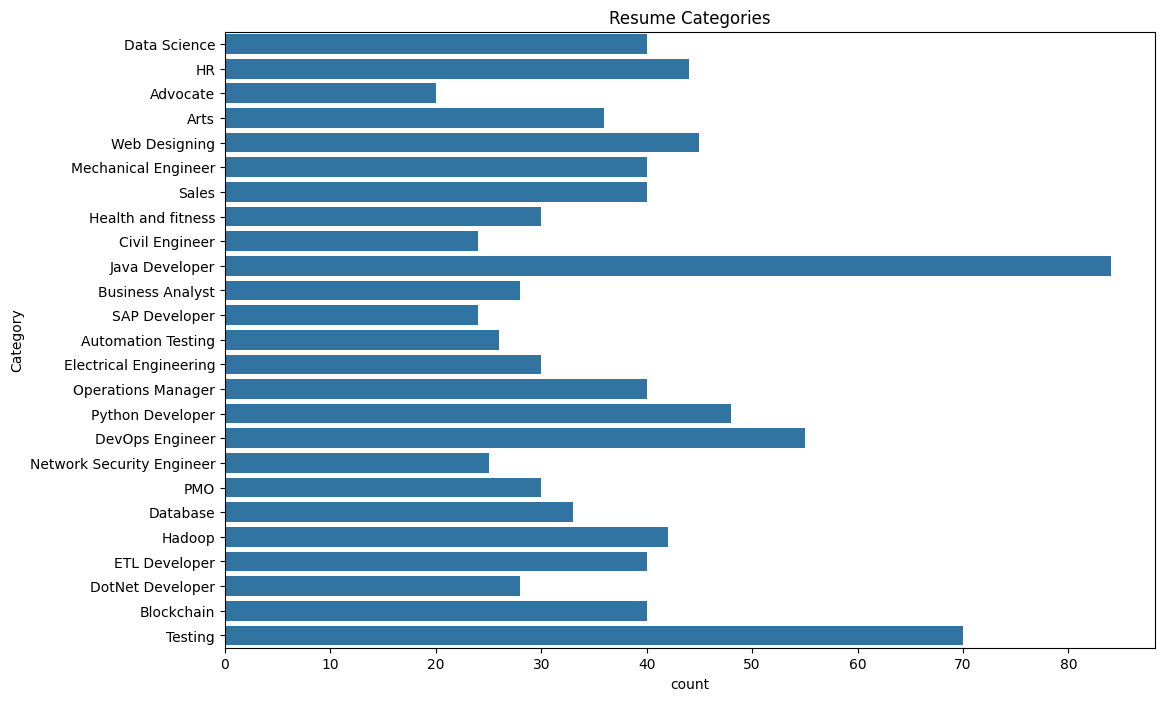

In [22]:
plt.figure(figsize=(12,8))

sns.countplot(y=df['Category'])

plt.title("Resume Categories")

plt.show()

In [23]:
import re
import string

In [24]:
def clean_resume(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'@\S+', ' ', text)

    text = re.sub(r'#\S+', ' ', text)

    text = re.sub(r'\d+', ' ', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = re.sub(r'\s+', ' ', text)

    return text

In [25]:
df['Resume'] = df['Resume'].apply(clean_resume)

df.head()

,Category,Resume
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may to may be uitrgpv data s...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,Data Science,education details mca ymcaust faridabad haryan...


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category'] = le.fit_transform(df['Category'])

df.head()

,Category,Resume
0,6,skills programming languages python pandas num...
1,6,education details may to may be uitrgpv data s...
2,6,areas of interest deep learning control system...
3,6,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,6,education details mca ymcaust faridabad haryan...


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['Resume'])

y = df['Category']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9948186528497409


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00         8
          17       1.00    

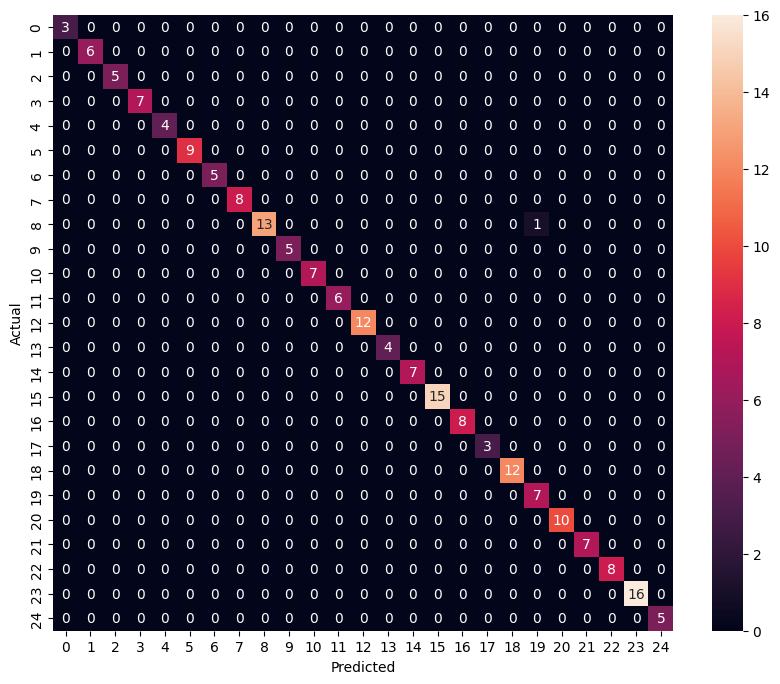

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
sample_resume = """

Python
Machine Learning
Deep Learning
NLP
TensorFlow
Data Analysis
SQL
Power BI

"""

sample = tfidf.transform([sample_resume])

prediction = model.predict(sample)

print(
    "Predicted Category:",
    le.inverse_transform(prediction)
)

Predicted Category: ['Data Science']


In [35]:
import pickle

pickle.dump(
    model,
    open("resume_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)